# NFXP — Empirical Application

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

Estimerer den strukturelle model på Netto-scannerpanelet.  
Denne notebook starter med at estimere **kun $\\alpha_2$** (brand 2-præference), mens alle øvrige parametre holdes fast.

**Parametre:**
$$\\theta = [\\alpha_0,\; \\alpha_2,\; \\gamma,\; \\beta^{sc}_{12},\; \\beta^{sc}_{21},\; \\beta^{dep}_1,\; \\beta^{dep}_2]$$

- $\\alpha_1 = 0$ er normaliseringen (som i MC-modellen)
- $\\alpha_0$ er no-purchase-konstantleddet (ekstra parameter i empirisk model)

## 1. Import

In [1]:
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

## 2. Model-dimensioner og konstanter

In [2]:
J        = 2       # antal brands
D_MAX    = 48      # durationsgrænse (uger siden sidst køb); 0 % capping i data
DELTA    = 0.95    # diskonteringsfaktor
N_CHOICES = J + 1  # {0=ingen køb, 1=brand 1, 2=brand 2}

EMPIRICAL_BRANDS        = [1, 2]
EMPIRICAL_PRICE_COLUMNS = {1: "Brand_1_price", 2: "Brand_2_price"}

# VFI-tolerancer
VFI_TOL     = 1e-10
VFI_MAXITER = 2_000
TRANS_SMOOTH = 1e-3   # Laplace-smoothing til overgangsmatrix

# ── Promotionstilstande ───────────────────────────────────────────────────────
# promo_states[s] = binær vektor over brands: 1 = kampagne aktiv
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)

print(f"J={J}, D_MAX={D_MAX}, N_CHOICES={N_CHOICES}, N_PROMO={N_PROMO}")
print("Promotionstilstande:", promo_states)

J=2, D_MAX=48, N_CHOICES=3, N_PROMO=4
Promotionstilstande: [[0 0]
 [1 0]
 [0 1]
 [1 1]]


## 3. Indlæs data

In [3]:
import pandas as pd
import numpy as np

# ── Datapaths ────────────────────────────────────────────────────────────────
SCANNER_DATA     = "/Users/solveigroendalliniger/Desktop/netto_df.csv"
PRICE_PROMO_DATA = "/Users/solveigroendalliniger/Desktop/Price_Promo.xlsx"
# ────────────────────────────────────────────────────────────────────────────


# ── Load scanner panel ──────────────────────────────────────────────────────
netto_df = pd.read_csv(SCANNER_DATA)

# Clean column names
netto_df.columns = netto_df.columns.astype(str).str.strip()

# Tjek nødvendige kolonner
scanner_required_columns = [
    "week_num",
    "Brand",
    "Price",
    "Customer_ID",
]

missing_scanner_columns = [
    col for col in scanner_required_columns
    if col not in netto_df.columns
]

if missing_scanner_columns:
    raise ValueError(
        f"Disse kolonner mangler i netto_df: {missing_scanner_columns}\n"
        f"Kolonner i netto_df er: {netto_df.columns.tolist()}"
    )

# Fjern uge 53
netto_df = netto_df[netto_df["week_num"] != 53].copy()

# Datatyper
netto_df["Brand"] = netto_df["Brand"].astype(str)

netto_df["Price"] = pd.to_numeric(
    netto_df["Price"],
    errors="coerce"
).round(1)

netto_df["Customer_ID"] = pd.to_numeric(
    netto_df["Customer_ID"],
    errors="coerce"
).astype("Int64")

netto_df["week_num"] = pd.to_numeric(
    netto_df["week_num"],
    errors="coerce"
).astype("Int64")

netto_df["brand_id"] = pd.to_numeric(
    netto_df["Brand"],
    errors="coerce"
).fillna(0).astype(int)


# ── Load price/promo Excel ──────────────────────────────────────────────────
price_promo_workbook = pd.ExcelFile(PRICE_PROMO_DATA)

print("Sheets in Price_Promo.xlsx:")
print(price_promo_workbook.sheet_names)

# Brug tredje sheet
price_promo_sheet_name = price_promo_workbook.sheet_names[2]
print(f"\nUsing sheet: {price_promo_sheet_name}")

price_promo_df = pd.read_excel(
    price_promo_workbook,
    sheet_name=price_promo_sheet_name
)

# Clean column names
price_promo_df.columns = price_promo_df.columns.astype(str).str.strip()


# ── Required price/promo columns ─────────────────────────────────────────────
price_promo_required_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Promo_Brand_1",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Promo_Brand_2",
]

missing_price_columns = [
    col for col in price_promo_required_columns
    if col not in price_promo_df.columns
]

if missing_price_columns:
    raise ValueError(
        f"Disse kolonner mangler i price_promo_df: {missing_price_columns}\n"
        f"Kolonner i arket er: {price_promo_df.columns.tolist()}"
    )

price_promo_df = price_promo_df[price_promo_required_columns].copy()


# ── Clean price/promo data ──────────────────────────────────────────────────
for col in price_promo_required_columns:
    price_promo_df[col] = pd.to_numeric(
        price_promo_df[col],
        errors="coerce"
    )

price_promo_df = price_promo_df.dropna(subset=["WeekNum"]).copy()
price_promo_df["WeekNum"] = price_promo_df["WeekNum"].astype(int)

# Tjek dubletter i uge
if price_promo_df["WeekNum"].duplicated().any():
    duplicated_weeks = (
        price_promo_df.loc[
            price_promo_df["WeekNum"].duplicated(),
            "WeekNum"
        ]
        .unique()
    )

    raise ValueError(
        f"Der er dubletter i WeekNum i price_promo_df: {duplicated_weeks}"
    )


# ── Construct binary offered prices directly ────────────────────────────────
# Pris = RRP hvis ingen kampagne
# Pris = gennemsnitlig kampagnepris hvis kampagne

# Promo skal være 0/1
price_promo_df["Promo_Brand_1"] = (
    price_promo_df["Promo_Brand_1"]
    .fillna(0)
    .astype(int)
)

price_promo_df["Promo_Brand_2"] = (
    price_promo_df["Promo_Brand_2"]
    .fillna(0)
    .astype(int)
)


# Brand 1: gennemsnitlig kampagnepris
mean_discount_brand_1 = price_promo_df.loc[
    (price_promo_df["Promo_Brand_1"] == 1) &
    (price_promo_df["Discount_Brand_1"].notna()),
    "Discount_Brand_1"
].mean()

if not np.isfinite(mean_discount_brand_1):
    mean_discount_brand_1 = price_promo_df["Discount_Brand_1"].mean()

if not np.isfinite(mean_discount_brand_1):
    mean_discount_brand_1 = price_promo_df["RRP_Brand_1"].median()


# Brand 2: gennemsnitlig kampagnepris
mean_discount_brand_2 = price_promo_df.loc[
    (price_promo_df["Promo_Brand_2"] == 1) &
    (price_promo_df["Discount_Brand_2"].notna()),
    "Discount_Brand_2"
].mean()

if not np.isfinite(mean_discount_brand_2):
    mean_discount_brand_2 = price_promo_df["Discount_Brand_2"].mean()

if not np.isfinite(mean_discount_brand_2):
    mean_discount_brand_2 = price_promo_df["RRP_Brand_2"].median()


# Gem gennemsnitlige kampagnepriser
price_promo_df["Mean_Discount_Brand_1"] = mean_discount_brand_1
price_promo_df["Mean_Discount_Brand_2"] = mean_discount_brand_2


# Lav de pris-kolonner, som merge skal bruge
price_promo_df["Brand_1_price"] = np.where(
    price_promo_df["Promo_Brand_1"] == 1,
    mean_discount_brand_1,
    price_promo_df["RRP_Brand_1"]
)

price_promo_df["Brand_2_price"] = np.where(
    price_promo_df["Promo_Brand_2"] == 1,
    mean_discount_brand_2,
    price_promo_df["RRP_Brand_2"]
)


# ── Safety check før merge ──────────────────────────────────────────────────
price_promo_merge_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

missing_merge_columns = [
    col for col in price_promo_merge_columns
    if col not in price_promo_df.columns
]

if missing_merge_columns:
    raise ValueError(
        f"Disse merge-kolonner mangler i price_promo_df: {missing_merge_columns}\n"
        f"Kolonner i price_promo_df er: {price_promo_df.columns.tolist()}"
    )


# ── Print price support ─────────────────────────────────────────────────────
empirical_binary_price_summary = pd.DataFrame(
    [
        {
            "Brand": 1,
            "RRP median": price_promo_df["RRP_Brand_1"].median(),
            "Mean sale price": mean_discount_brand_1,
            "Promo weeks": int(price_promo_df["Promo_Brand_1"].sum()),
        },
        {
            "Brand": 2,
            "RRP median": price_promo_df["RRP_Brand_2"].median(),
            "Mean sale price": mean_discount_brand_2,
            "Promo weeks": int(price_promo_df["Promo_Brand_2"].sum()),
        },
    ]
)

print("\nBinary empirical price support:")
print(
    empirical_binary_price_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)


print("\nPrice/promo preview:")
print(
    price_promo_df[
        [
            "WeekNum",
            "RRP_Brand_1",
            "Promo_Brand_1",
            "Brand_1_price",
            "RRP_Brand_2",
            "Promo_Brand_2",
            "Brand_2_price",
        ]
    ]
    .head(10)
)
# ── Fjern gamle price/promo-kolonner fra netto_df før merge ─────────────────
old_price_promo_cols = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

# Fjern også evt. _x og _y kolonner fra tidligere merges
old_price_promo_cols_extended = old_price_promo_cols.copy()

for col in old_price_promo_cols:
    old_price_promo_cols_extended.append(f"{col}_x")
    old_price_promo_cols_extended.append(f"{col}_y")

netto_df = netto_df.drop(
    columns=[col for col in old_price_promo_cols_extended if col in netto_df.columns]
)

# ── Merge weekly price/promo data onto scanner panel ────────────────────────
netto_df = netto_df.merge(
    price_promo_df[price_promo_merge_columns],
    left_on="week_num",
    right_on="WeekNum",
    how="left",
    validate="many_to_one"
)


# ── Keep only rows with both alternative prices available ───────────────────
netto_df = netto_df.loc[
    netto_df["Brand_1_price"].notna() &
    netto_df["Brand_2_price"].notna()
].copy()


# ── Final check ─────────────────────────────────────────────────────────────
print(
    f"\nPanel: {netto_df['Customer_ID'].nunique():,} husstande, "
    f"{netto_df['week_num'].nunique()} uger"
)

print("\nFirst rows:")
display(netto_df.head())

Sheets in Price_Promo.xlsx:
['_com.sap.ip.bi.xl.hiddensheet', 'Sheet1', 'Sheet2', 'Sheet3']

Using sheet: Sheet2

Binary empirical price support:
 Brand  RRP median  Mean sale price  Promo weeks
     1      24.950            9.842           10
     2      11.950            9.993            6

Price/promo preview:
   WeekNum  RRP_Brand_1  Promo_Brand_1  Brand_1_price  RRP_Brand_2  \
0        1        24.95              0      24.950000        11.95   
1        2        24.95              0      24.950000        11.95   
2        3        24.95              0      24.950000        11.95   
3        4        24.95              0      24.950000        11.95   
4        5        24.95              0      24.950000        11.95   
5        6        24.95              0      24.950000        11.95   
6        7        24.95              0      24.950000        11.95   
7        8        24.95              1       9.842316        11.95   
8        9        24.95              0      24.950000  

,Unnamed: 0,Customer_ID,week_num,y,Brand,Quantity,promo_flag,Price,last_purchase_week,duration,...,RRP_Brand_1,Discount_Brand_1,Mean_Discount_Brand_1,Promo_Brand_1,Brand_1_price,RRP_Brand_2,Discount_Brand_2,Mean_Discount_Brand_2,Promo_Brand_2,Brand_2_price
0,1,1,1,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
1,2,1,2,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
2,3,1,3,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
3,4,1,4,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
4,5,1,5,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95


## 4. Empirisk prisproces

Estimér den ugentlige overgangsmatrix for kampagnetilstande og median-priser per tilstand fra dataene.

In [4]:
def empirical_promo_idx(frame: pd.DataFrame) -> np.ndarray:
    """Mappe Promo_Brand_1/2 til indeks i promo_states."""
    mat = frame[[f"Promo_Brand_{b}" for b in EMPIRICAL_BRANDS]].fillna(0).astype(int).to_numpy()
    return mat @ (2 ** np.arange(J))


def build_weekly_state_table(data: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        data[["week_num", "Brand_1_price", "Brand_2_price", "Promo_Brand_1", "Promo_Brand_2"]]
        .dropna().drop_duplicates().sort_values("week_num").reset_index(drop=True)
    )
    weekly["promo_idx"] = empirical_promo_idx(weekly)
    return weekly


def estimate_promo_transition(weekly: pd.DataFrame, smoothing=TRANS_SMOOTH) -> np.ndarray:
    idx = weekly["promo_idx"].to_numpy(dtype=int)
    counts = np.full((N_PROMO, N_PROMO), smoothing)
    np.add.at(counts, (idx[:-1], idx[1:]), 1.0)
    return counts / counts.sum(axis=1, keepdims=True)


def build_price_by_promo(weekly: pd.DataFrame) -> np.ndarray:
    pbp = np.full((N_PROMO, J), np.nan)
    for s in range(N_PROMO):
        rows = weekly.loc[weekly["promo_idx"] == s]
        if len(rows) == 0:
            continue
        for b_idx, b in enumerate(EMPIRICAL_BRANDS):
            pbp[s, b_idx] = rows[EMPIRICAL_PRICE_COLUMNS[b]].median()
    # Fallback for unobserverede tilstande
    for s, pvec in enumerate(promo_states):
        for b_idx, b in enumerate(EMPIRICAL_BRANDS):
            if np.isfinite(pbp[s, b_idx]):
                continue
            fb = weekly.loc[
                weekly[f"Promo_Brand_{b}"].astype(int) == int(pvec[b_idx]),
                EMPIRICAL_PRICE_COLUMNS[b]
            ].median()
            pbp[s, b_idx] = fb if np.isfinite(fb) else weekly[EMPIRICAL_PRICE_COLUMNS[b]].median()
    return pbp


weekly_state     = build_weekly_state_table(netto_df)
PROMO_TRANS      = estimate_promo_transition(weekly_state)
PRICE_BY_PROMO   = build_price_by_promo(weekly_state)

lbl = [f"e={tuple(int(v) for v in r)}" for r in promo_states]
print("Priser per kampagnetilstand:")
print(pd.DataFrame(PRICE_BY_PROMO, index=lbl, columns=["Brand 1", "Brand 2"]).to_string(float_format=lambda x: f"{x:.3f}"))
print("\nEstimeret ugentlig overgangsmatrix:")
print(pd.DataFrame(PROMO_TRANS, index=lbl, columns=lbl).to_string(float_format=lambda x: f"{x:.3f}"))

Priser per kampagnetilstand:
          Brand 1  Brand 2
e=(0, 0)   24.950   11.950
e=(1, 0)    9.842   11.950
e=(0, 1)   24.950    9.993
e=(1, 1)    9.842    9.993

Estimeret ugentlig overgangsmatrix:
          e=(0, 0)  e=(1, 0)  e=(0, 1)  e=(1, 1)
e=(0, 0)     0.722     0.167     0.083     0.028
e=(1, 0)     0.666     0.222     0.111     0.000
e=(0, 1)     0.600     0.200     0.200     0.000
e=(1, 1)     0.997     0.001     0.001     0.001


## 5. Panelforberedelse

Rekonstruér tilstandsvariablerne $( \\ell_{it}, d_{it}, e_t )$ fra det observerede panel og aggregér til state-choice counts.

In [5]:
def prepare_panel(data: pd.DataFrame, d_max: int = D_MAX):
    panel = data.sort_values(["Customer_ID", "week_num"]).copy()
    panel["choice"] = panel["brand_id"].where(panel["brand_id"].isin(EMPIRICAL_BRANDS), 0).astype(int)
    panel["purchase_brand"] = panel["choice"].where(panel["choice"] > 0)
    panel["purchase_week"]  = panel["week_num"].where(panel["choice"] > 0)

    grp = panel.groupby("Customer_ID", sort=False)
    panel["last_brand_incl"] = grp["purchase_brand"].ffill()
    panel["last_week_incl"]  = grp["purchase_week"].ffill()
    panel["pre_last_brand"]  = grp["last_brand_incl"].shift(1)
    panel["pre_last_week"]   = grp["last_week_incl"].shift(1)
    panel["pre_dur_weeks"]   = panel["week_num"] - panel["pre_last_week"]

    usable = panel.loc[
        panel["pre_last_brand"].isin(EMPIRICAL_BRANDS)
        & panel["pre_dur_weeks"].notna()
        & panel["Promo_Brand_1"].notna()
        & panel["Promo_Brand_2"].notna()
    ].copy()

    usable["Y"]     = usable["choice"].astype(int)
    usable["L"]     = usable["pre_last_brand"].astype(int)
    usable["D"]     = np.clip(usable["pre_dur_weeks"].to_numpy(dtype=float) - 1.0, 0, d_max).astype(int)
    usable["E_IDX"] = empirical_promo_idx(usable)

    counts = np.zeros((J, d_max + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (usable["L"].to_numpy() - 1, usable["D"].to_numpy(),
         usable["E_IDX"].to_numpy(), usable["Y"].to_numpy()),
        1.0,
    )
    return usable, counts


panel_df, OBS_COUNTS = prepare_panel(netto_df)
N_OBS = int(OBS_COUNTS.sum())

choice_shares = OBS_COUNTS.sum(axis=(0, 1, 2)) / N_OBS
print(f"Observationer: {N_OBS:,}")
print(f"  Ingen køb: {choice_shares[0]:.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:    {choice_shares[j]:.1%}")
print(f"  Duration cap: {D_MAX}  |  Cappede: {(panel_df['D'] == D_MAX).mean():.1%}")

Observationer: 1,697,631
  Ingen køb: 84.8%
  Brand 1:    3.4%
  Brand 2:    11.8%
  Duration cap: 48  |  Cappede: 0.0%


## 6. Vectoriseret empirisk VFI og CCPs

Samme logik som i MC-notebooken, men med:
- Estimeret `PROMO_TRANS` fra data
- Observerede `PRICE_BY_PROMO` fra data  
- Ekstra $\\alpha_0$ (no-purchase konstantled)

$$Q_0(\\ell, d, e) = \\alpha_0 + \\alpha_\\ell - \\beta^{dep}_\\ell \\cdot d + \\delta \\cdot EV(\\ell, d+1, e')$$
$$Q_j(\\ell, d, e) = \\alpha_j - \\gamma \\cdot p_j(e) - \\beta^{sc}_{\\ell j} + \\delta \\cdot EV(j, 1, e')$$

In [6]:
def solve_vfi(
    alpha_0: float,
    alpha: np.ndarray,
    gamma: float,
    beta_sc: np.ndarray,
    beta_dep: np.ndarray,
    tol: float = VFI_TOL,
    max_iter: int = VFI_MAXITER,
) -> np.ndarray:
    """
    Vectoriseret VFI for den empiriske model.
    V shape: (J, D_MAX+1, N_PROMO).
    """
    dur_idx  = np.arange(D_MAX + 1)
    duration = dur_idx + 1.0
    next_dur = np.minimum(dur_idx + 1, D_MAX)

    # No-purchase nyttekomponent (J, D_MAX+1)
    no_purch = alpha_0 + alpha[:, None] - beta_dep[:, None] * duration[None, :]

    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    V = np.zeros((J, D_MAX + 1, N_PROMO))

    for _ in range(max_iter):
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX + 1, N_PROMO)

        # Ingen køb: næste tilstand er (ℓ, min(d+1, D_MAX))
        Q[..., 0] = no_purch[:, :, None] + DELTA * EV[:, next_dur, :]

        # Køb brand j: næste tilstand er (j, d=0)
        for j in range(J):
            Q[..., j + 1] = (
                alpha[j]
                - gamma * PRICE_BY_PROMO[:, j][None, None, :]   # (1,1,N_PROMO)
                - beta_sc[:, j][:, None, None]                  # (J,1,1)
                + DELTA * EV[j, 0, :][None, None, :]             # (1,1,N_PROMO)
            )

        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V


def compute_ccps(
    V: np.ndarray,
    alpha_0: float,
    alpha: np.ndarray,
    gamma: float,
    beta_sc: np.ndarray,
    beta_dep: np.ndarray,
) -> np.ndarray:
    """CCP'er. P shape: (J, D_MAX+1, N_PROMO, N_CHOICES)."""
    dur_idx  = np.arange(D_MAX + 1)
    duration = dur_idx + 1.0
    next_dur = np.minimum(dur_idx + 1, D_MAX)

    no_purch = alpha_0 + alpha[:, None] - beta_dep[:, None] * duration[None, :]
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX + 1, N_PROMO)

    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    Q[..., 0] = no_purch[:, :, None] + DELTA * EV[:, next_dur, :]
    for j in range(J):
        Q[..., j + 1] = (
            alpha[j]
            - gamma * PRICE_BY_PROMO[:, j][None, None, :]
            - beta_sc[:, j][:, None, None]
            + DELTA * EV[j, 0, :][None, None, :]
        )

    w = np.exp(Q - Q.max(axis=3, keepdims=True))
    return w / w.sum(axis=3, keepdims=True)


def log_lik(counts: np.ndarray, P: np.ndarray) -> float:
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))


print("VFI og CCP-funktioner klar.")

VFI og CCP-funktioner klar.


## 7. Fastlagte parametre

Alle parametre undtagen $\\alpha_2$ holdes fast.  
Tilpas disse værdier efter behov.

In [7]:
# ── Fastlagte parametre ───────────────────────────────────────────────────────
FIXED_ALPHA_0   = 2.00    # no-purchase konstantled
FIXED_GAMMA     = 0.05    # marginal prisaversion
FIXED_BETA_SC   = np.array([[0.00, 0.25],
                             [0.25, 0.00]])   # switching costs
FIXED_BETA_DEP  = np.array([0.275, 0.275])   # deprecieringsrater

# alpha_1 = 0 er normaliseringen
def make_alpha(alpha_2: float) -> np.ndarray:
    return np.array([0.0, alpha_2])


def neg_ll_alpha2(alpha_2: float) -> float:
    """Negativ log-likelihood som funktion af alpha_2 alene."""
    alpha = make_alpha(alpha_2)
    V = solve_vfi(FIXED_ALPHA_0, alpha, FIXED_GAMMA, FIXED_BETA_SC, FIXED_BETA_DEP)
    P = compute_ccps(V, FIXED_ALPHA_0, alpha, FIXED_GAMMA, FIXED_BETA_SC, FIXED_BETA_DEP)
    return -log_lik(OBS_COUNTS, P)


print("Fastlagte parametre:")
print(f"  alpha_0   = {FIXED_ALPHA_0}")
print(f"  gamma     = {FIXED_GAMMA}")
print(f"  beta_sc   = {FIXED_BETA_SC}")
print(f"  beta_dep  = {FIXED_BETA_DEP}")

Fastlagte parametre:
  alpha_0   = 2.0
  gamma     = 0.05
  beta_sc   = [[0.   0.25]
 [0.25 0.  ]]
  beta_dep  = [0.275 0.275]


## 8. Grid search over $\\alpha_2$

Groft gitter for at kortlægge likelihood-overfladen og finde et godt startpunkt.

In [8]:
GRID = np.linspace(-1.0, 3.0, 25)

t0 = time.perf_counter()
ll_grid = []
for i, a2 in enumerate(GRID):
    nll = neg_ll_alpha2(float(a2))
    ll_grid.append(-nll)
    if (i + 1) % 5 == 0:
        print(f"  Grid {i+1:>2}/{len(GRID)}  alpha_2={a2:+.3f}  LL={-nll:.1f}")

ll_grid = np.array(ll_grid)
best_grid_idx = int(np.argmax(ll_grid))
print(f"\nBedste gitterpunkt: alpha_2 = {GRID[best_grid_idx]:.3f}  (LL={ll_grid[best_grid_idx]:.1f})")
print(f"Grid-søgning tog {time.perf_counter() - t0:.1f}s")

  Grid  5/25  alpha_2=-0.333  LL=-2426250.7
  Grid 10/25  alpha_2=+0.500  LL=-2364556.8
  Grid 15/25  alpha_2=+1.333  LL=-2698506.6
  Grid 20/25  alpha_2=+2.167  LL=-3077608.6
  Grid 25/25  alpha_2=+3.000  LL=-3465628.3

Bedste gitterpunkt: alpha_2 = 0.167  (LL=-2291659.9)
Grid-søgning tog 0.6s


## 9. Finpudsning med `minimize_scalar`

In [9]:
# Start i det bedste gitterpunkt; søg i et vindue omkring det
a2_lo = float(GRID[max(best_grid_idx - 2, 0)])
a2_hi = float(GRID[min(best_grid_idx + 2, len(GRID) - 1)])

t0 = time.perf_counter()
res = minimize_scalar(
    neg_ll_alpha2,
    bounds=(a2_lo, a2_hi),
    method="bounded",
    options={"xatol": 1e-6, "maxiter": 200},
)
elapsed = time.perf_counter() - t0

ALPHA_2_HAT = float(res.x)
LL_HAT      = -float(res.fun)

print(f"Konvergeret: {res.success}  |  Iterationer: {res.nit}  |  Tid: {elapsed:.1f}s")
print(f"\n{'='*40}")
print(f"  alpha_2_hat = {ALPHA_2_HAT:.6f}")
print(f"  Log-lik     = {LL_HAT:.2f}")
print(f"{'='*40}")

Konvergeret: True  |  Iterationer: 9  |  Tid: 0.2s

  alpha_2_hat = 0.093259
  Log-lik     = -2288429.27


## 10. Likelihood-kurve og estimat

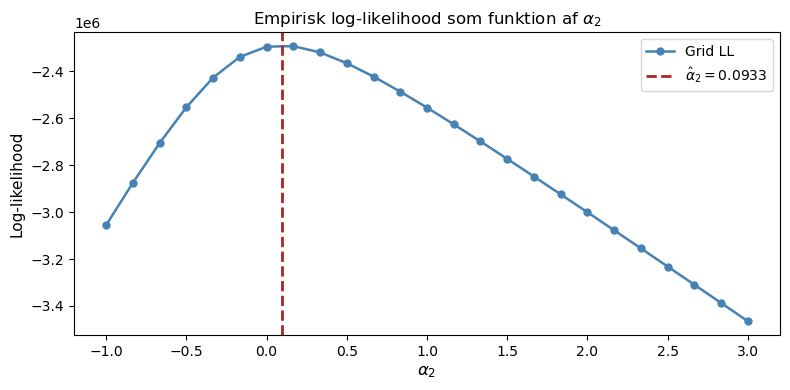


Observerede vs. forudsagte valgsandsynligheder:
     Valg  Observeret andel  Forudsagt andel  Forskel
Ingen køb            0.8479           0.4424  -0.4055
  Brand 1            0.0337           0.1609   0.1272
  Brand 2            0.1184           0.3967   0.2783


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(GRID, ll_grid, "o-", color="steelblue", lw=1.8, ms=5, label="Grid LL")
ax.axvline(ALPHA_2_HAT, color="firebrick", lw=2, ls="--",
           label=rf"$\hat{{\alpha}}_2 = {ALPHA_2_HAT:.4f}$")
ax.set_xlabel(r"$\alpha_2$", fontsize=12)
ax.set_ylabel("Log-likelihood", fontsize=11)
ax.set_title(r"Empirisk log-likelihood som funktion af $\alpha_2$", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("nfxp_empirical_alpha2.pdf", bbox_inches="tight")
plt.show()

# Tilpassede vs. observerede valgsandsynligheder
alpha_hat = make_alpha(ALPHA_2_HAT)
V_hat = solve_vfi(FIXED_ALPHA_0, alpha_hat, FIXED_GAMMA, FIXED_BETA_SC, FIXED_BETA_DEP)
P_hat = compute_ccps(V_hat, FIXED_ALPHA_0, alpha_hat, FIXED_GAMMA, FIXED_BETA_SC, FIXED_BETA_DEP)

state_counts = OBS_COUNTS.sum(axis=3)
obs_shares   = OBS_COUNTS.sum(axis=(0, 1, 2)) / N_OBS
pred_shares  = (state_counts[..., None] * P_hat).sum(axis=(0, 1, 2)) / N_OBS

fit_table = pd.DataFrame({
    "Valg":               ["Ingen køb", "Brand 1", "Brand 2"],
    "Observeret andel":   obs_shares,
    "Forudsagt andel":    pred_shares,
    "Forskel":            pred_shares - obs_shares,
})
print("\nObserverede vs. forudsagte valgsandsynligheder:")
print(fit_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))